In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import random
import sys
from scipy.stats import norm, poisson, chi2
from scipy.integrate import quad
from iminuit import Minuit
from iminuit.cost import LeastSquares

In [2]:
#def grafici plot fit RL/RC
def plot_fit_ampiezza (x_coord, y_coord, y_sigma, fit_function, minuit_object, f_taglio , title = '') :
    """
    Plots the data and the best-fit function using iminuit fit results.

    Parameters:
    - x_coord: array of x values (data)
    - y_coord: array of y values (data)
    - y_sigma: aray of y uncertainties (data)
    - fit_function: the model function used for fitting
    - minuit_object: the iminuit Minuit instance after fitting
    """
    fig, ax = plt.subplots ()
    ax.errorbar (x_coord, y_coord, xerr = 01.0, yerr = y_sigma, linestyle = 'None', marker = 'o', label='dati sperimentali')

    x_fit = np.linspace (x_coord[0], x_coord[-1], 1000)
    best_params = {key: minuit_object.values[key] for key in minuit_object.parameters}
    y_fit = fit_function (x_fit, **best_params)  # Evaluate function with best-fit params
    ax.plot (x_fit, y_fit, color="forestgreen", linewidth=2, label= 'fit' )
    plt.axvline(x = f_taglio, linestyle = '--', color = 'red', label= 'taglio teorico')
    ax.set_xlabel ("frequenza")
    ax.set_ylabel ("ampiezza")
    ax.set_title (title)

    #plt.savefig("R=5k_cb_C1.png")
    ax.legend()
    plt.show()
    #plt.close(fig)

def plot_fit_ampiezza_log (x_coord, y_coord, y_sigma, fit_function, minuit_object, f_taglio, title = '') :
    """
    Plots the data and the best-fit function using iminuit fit results.

    Parameters:
    - x_coord: array of x values (data)
    - y_coord: array of y values (data)
    - y_sigma: aray of y uncertainties (data)
    - fit_function: the model function used for fitting
    - minuit_object: the iminuit Minuit instance after fitting
    """
    fig, ax = plt.subplots ()
    ax.errorbar (x_coord, y_coord, xerr = 01.0, yerr = y_sigma, linestyle = 'None', marker = 'o', label='dati sperimentali')

    x_fit = np.linspace (x_coord[0], x_coord[-1], 1000)
    best_params = {key: minuit_object.values[key] for key in minuit_object.parameters}
    y_fit = fit_function (x_fit, **best_params)  # Evaluate function with best-fit params
    ax.plot (x_fit, y_fit, color="forestgreen", linewidth=2, label= 'fit' )
    plt.axvline(x = f_taglio, linestyle = '--', color = 'red', label= 'taglio teorico')
    ax.set_xlabel ("frequenza")
    ax.set_ylabel ("ampiezza")
    plt.xscale('log')
    plt.yscale('log')
    ax.set_title (title)

    #plt.savefig("R=5k_cb_C1.png")
    ax.legend()
    plt.show()
    #plt.close(fig)

def plot_fit_fase (x_coord, y_coord, y_sigma, fit_function, minuit_object,f_taglio,  title = '') :
    """
    Plots the data and the best-fit function using iminuit fit results.

    Parameters:
    - x_coord: array of x values (data)
    - y_coord: array of y values (data)
    - y_sigma: aray of y uncertainties (data)
    - fit_function: the model function used for fitting
    - minuit_object: the iminuit Minuit instance after fitting
    """
    fig, ax = plt.subplots ()
    ax.errorbar (x_coord, y_coord, xerr = 01.0, yerr = y_sigma, linestyle = 'None', marker = 'o', label= 'dati sperimentali')

    x_fit = np.linspace (x_coord[0], x_coord[-1], 1000)
    best_params = {key: minuit_object.values[key] for key in minuit_object.parameters}
    y_fit = fit_function (x_fit, **best_params)  # Evaluate function with best-fit params
    ax.plot (x_fit, y_fit, color="forestgreen", linewidth=2, label='fit')
    plt.axvline(x = f_taglio, linestyle = '--', color = 'red', label= 'taglio teorico')
    ax.set_xlabel ("frequenza")
    ax.set_ylabel ("fase")
    ax.set_title (title)

    #plt.savefig("R=5k_cb_C1.png")
    ax.legend()
    plt.show()
    #plt.close(fig)

def plot_fit_fase_log (x_coord, y_coord, y_sigma, fit_function, minuit_object,f_taglio, title = '') :
    """
    Plots the data and the best-fit function using iminuit fit results.

    Parameters:
    - x_coord: array of x values (data)
    - y_coord: array of y values (data)
    - y_sigma: aray of y uncertainties (data)
    - fit_function: the model function used for fitting
    - minuit_object: the iminuit Minuit instance after fitting
    """
    fig, ax = plt.subplots ()
    ax.errorbar (x_coord, y_coord, xerr = 01.0, yerr = y_sigma, linestyle = 'None', marker = 'o', label= 'dati sperimentali')

    x_fit = np.linspace (x_coord[0], x_coord[-1], 1000)
    best_params = {key: minuit_object.values[key] for key in minuit_object.parameters}
    y_fit = fit_function (x_fit, **best_params)  # Evaluate function with best-fit params
    ax.plot (x_fit, y_fit, color="forestgreen", linewidth=2, label='fit')
    plt.axvline(x = f_taglio, linestyle = '--', color = 'red', label= 'taglio teorico')
    ax.set_xlabel ("frequenza")
    ax.set_ylabel ("fase")
    ax.set_title (title)
    plt.xscale('log')
    plt.yscale('log')
    #plt.savefig("R=5k_cb_C1.png")
    ax.legend()
    plt.show()
    #plt.close(fig)

def plot_fit_fase_logx (x_coord, y_coord, y_sigma, fit_function, minuit_object,f_taglio, title = '') :
    """
    Plots the data and the best-fit function using iminuit fit results.

    Parameters:
    - x_coord: array of x values (data)
    - y_coord: array of y values (data)
    - y_sigma: aray of y uncertainties (data)
    - fit_function: the model function used for fitting
    - minuit_object: the iminuit Minuit instance after fitting
    """
    fig, ax = plt.subplots ()
    ax.errorbar (x_coord, y_coord, xerr = 01.0, yerr = y_sigma, linestyle = 'None', marker = 'o', label= 'dati sperimentali')

    x_fit = np.linspace (x_coord[0], x_coord[-1], 1000)
    best_params = {key: minuit_object.values[key] for key in minuit_object.parameters}
    y_fit = fit_function (x_fit, **best_params)  # Evaluate function with best-fit params
    ax.plot (x_fit, y_fit, color="forestgreen", linewidth=2, label='fit')
    plt.axvline(x = f_taglio, linestyle = '--', color = 'red', label= 'taglio teorico')
    ax.set_xlabel ("frequenza")
    ax.set_ylabel ("fase")
    ax.set_title (title)
    plt.xscale('log')
    #plt.savefig("R=5k_cb_C1.png")
    ax.legend()
    plt.show()
    #plt.close(fig)

In [3]:
R_us=673 #ohm
errL = 0.0008 #H
Ci = 1.0308338202525391e-07
errC = 6e-10
Rl=7.8
Li1= 0.00477
Li2= 0.00468

In [4]:
#parte 1 rl
#taglio teorico RL
tau_a= Li1/R_us
f=(1/tau_a)/(2*np.pi)
print(tau_a)
print(f)

7.087667161961367e-06
22455.194276906826


In [5]:
#funzioni RL
def HR (f, R, L):
    return (2 * np.pi * f * L) / np.sqrt(R ** 2 + (2 * np.pi * f * L) ** 2)

def HL (f, R, L):
    return R / np.sqrt(R ** 2 + (2 * np.pi * f * L) ** 2)

def argHR (f, R, L ):
    return np.pi / 2 - np.arctan((2 * np.pi * L * f) / R)

def argHL (f, R, L ):
    return - np.arctan((2 * np.pi * L * f) / R)

In [6]:
with open('C3RL.txt') as input_file:
    Fllist = []
    HLllist = []
    errHLllist= []
    errHRllist= []
    HRllist = []
    argHLlist = []
    argHRlist = []
    for riga in input_file:
        valoriLC = riga.split()
        Fllist.append(float(valoriLC[0]))
        HLllist.append(float(valoriLC[1]))
        HRllist.append(float(valoriLC[2]))
        argHLlist.append(float(valoriLC[3]))
        argHRlist.append(float(valoriLC[4]))
        errHLllist.append(float(valoriLC[5]))
        errHRllist.append(float(valoriLC[6]))
faseHLlist = np.radians(argHLlist)
faseHRlist = np.radians(argHRlist)


Fl = Fllist
HLl = HLllist
errHLl = errHLllist
errHRl = errHRllist
HRl = HRllist
faseHR = faseHRlist
faseHL = faseHLlist

Fl = np.array(Fllist)
HLl = np.array(HLllist)
errHLl = np.array(errHLl)
errHRl = np.array(errHRl)
HRl = np.array(HRllist)
faseHL = np.array(faseHLlist)
faseHR = np.array(faseHRlist)


In [7]:
#minimi quadrati funzione di trasferimento HL
least_squares = LeastSquares (Fl, HLl, errHLl, HL)
my_minuit1 = Minuit (least_squares, L=0.003, R= 100)
my_minuit1.limits["L"] = (0.0034, 0.005)
my_minuit1.limits["R"] = (520, 680)
my_minuit1.migrad ()
my_minuit1.hesse ()


is_valid = my_minuit1.valid
print ('success of the fit: ', is_valid)

Q_squared = my_minuit1.fval
print ('value of the fit Q-squared', Q_squared)
N_dof = my_minuit1.ndof
print ('value of the number of degrees of freedom', N_dof)

from scipy.stats import chi2
print ('associated p-value: ', 1. - chi2.cdf (my_minuit1.fval, df = my_minuit1.ndof))

for par, val, err in zip (my_minuit1.parameters, my_minuit1.values, my_minuit1.errors) :
    print(f'{par} = {val:.3f} +/- {err:.3f}') # formatted output

L_fit = my_minuit1.values[1]
erL = my_minuit1.errors[1]
R_fit = my_minuit1.values[0]
erR =my_minuit1.errors[0]


print (my_minuit1.covariance)


display (my_minuit1)

success of the fit:  True
value of the fit Q-squared 4.987106381662644
value of the number of degrees of freedom 11.0
associated p-value:  0.9317894272043086
R = 523.020 +/- 80.621
L = 0.004 +/- 0.001
┌───┬─────────────────────────┐
│   │           R           L │
├───┼─────────────────────────┤
│ R │    1.91e+04 131.1340e-3 │
│ L │ 131.1340e-3    9.04e-07 │
└───┴─────────────────────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 4.987 (χ²/ndof = 0.5)      │              Nfcn = 81               │
│ EDM = 9.94e-12 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │     Covariance FORCED pos. def.      │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ R    │    520    │    80     │            │            │   520   │   680   │       │
│ 1 │ L    │  3.6e-3   │  0.9e-3   │            │            │ 0.0034  │  0.005  │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬─────────────────────────┐
│   │           R           L │
├───┼─────────────────────────┤
│ R │    1.91e+04 131.1340e-3 │
│ L │ 131.1340e-3    9.04e-07 │
└───┴─────────────────────────┘

In [8]:
t_student_R=((R_us+Rl)-R_fit)/erR
t_student_L= (Li1-L_fit)/erL
print(L_fit, erL, R_fit, erR)
print(t_student_L, t_student_R)

0.0035971332742437767 0.0009165762433502218 523.020496099846 80.6212135542113
1.2796171996223922 1.9570469972404954


In [9]:
#minimi quadrati funzione di trasferimento HR
least_squares = LeastSquares (Fl, HRl, errHRl, HR)
my_minuit2 = Minuit (least_squares, L=0.004, R= 100)
my_minuit2.limits["L"] = (0.003, 0.006)
my_minuit2.limits["R"] = (500, 700)
my_minuit2.migrad ()
my_minuit2.hesse ()


is_valid = my_minuit2.valid
print ('success of the fit: ', is_valid)

Q_squared = my_minuit2.fval
print ('value of the fit Q-squared', Q_squared)
N_dof = my_minuit2.ndof
print ('value of the number of degrees of freedom', N_dof)

from scipy.stats import chi2
print ('associated p-value: ', 1. - chi2.cdf (my_minuit2.fval, df = my_minuit2.ndof))

for par, val, err in zip (my_minuit2.parameters, my_minuit2.values, my_minuit2.errors) :
    print(f'{par} = {val:.3f} +/- {err:.3f}') # formatted output

L_fit = my_minuit2.values[1]
erL = my_minuit2.errors[1]
R_fit = my_minuit2.values[0]
erR =my_minuit2.errors[0]


print (my_minuit2.covariance)


display (my_minuit2)

success of the fit:  True
value of the fit Q-squared 3.063771624481811
value of the number of degrees of freedom 11.0
associated p-value:  0.9898559587021731
R = 566.313 +/- 77.735
L = 0.004 +/- 0.001
┌───┬───────────────────────┐
│   │          R          L │
├───┼───────────────────────┤
│ R │   8.36e+03 57.3961e-3 │
│ L │ 57.3961e-3   3.95e-07 │
└───┴───────────────────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.064 (χ²/ndof = 0.3)      │              Nfcn = 65               │
│ EDM = 2.26e-08 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │     Covariance FORCED pos. def.      │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ R    │    570    │    80     │            │            │   500   │   700   │       │
│ 1 │ L    │  3.9e-3   │  0.6e-3   │            │            │  0.003  │  0.006  │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬───────────────────────┐
│   │          R          L │
├───┼───────────────────────┤
│ R │   8.36e+03 57.3961e-3 │
│ L │ 57.3961e-3   3.95e-07 │
└───┴───────────────────────┘

In [10]:
t_student_R=((R_us+Rl)-R_fit)/erR
t_student_L= (Li1-L_fit)/erL
print(L_fit, erL, R_fit, erR)
print(t_student_L, t_student_R)

0.0038943413671507893 0.0006070929198445461 566.313431674767 77.73506602117052
1.4423799129026809 1.4727789424408986


In [11]:
#minimi quadrati funzione di trasferimento fase HL
least_squares = LeastSquares (Fl, faseHL, faseHL*(5/100), argHL)
my_minuit3 = Minuit (least_squares, L=0.004, R= 100)
my_minuit3.limits["L"] = (0.003, 0.006)
my_minuit3.limits["R"] = (500, 700)
my_minuit3.migrad ()
my_minuit3.hesse ()


is_valid = my_minuit3.valid
print ('success of the fit: ', is_valid)

Q_squared = my_minuit3.fval
print ('value of the fit Q-squared', Q_squared)
N_dof = my_minuit3.ndof
print ('value of the number of degrees of freedom', N_dof)

from scipy.stats import chi2
print ('associated p-value: ', 1. - chi2.cdf (my_minuit3.fval, df = my_minuit3.ndof))

for par, val, err in zip (my_minuit3.parameters, my_minuit3.values, my_minuit3.errors) :
    print(f'{par} = {val:.3f} +/- {err:.3f}') # formatted output

L_fit = my_minuit3.values[1]
erL = my_minuit3.errors[1]
R_fit = my_minuit3.values[0]
erR =my_minuit3.errors[0]

print (my_minuit3.covariance)


display(my_minuit3)

success of the fit:  True
value of the fit Q-squared 29.112873164202835
value of the number of degrees of freedom 11.0
associated p-value:  0.0021801844295558093
R = 584.573 +/- 137.120
L = 0.004 +/- 0.001
┌───┬─────────────────────────┐
│   │           R           L │
├───┼─────────────────────────┤
│ R │    3.43e+04 228.7568e-3 │
│ L │ 228.7568e-3    1.53e-06 │
└───┴─────────────────────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 29.11 (χ²/ndof = 2.6)      │              Nfcn = 65               │
│ EDM = 2.71e-10 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │     Covariance FORCED pos. def.      │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ R    │  0.58e3   │  0.14e3   │            │            │   500   │   700   │       │
│ 1 │ L    │  0.0039   │  0.0011   │            │            │  0.003  │  0.006  │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬─────────────────────────┐
│   │           R           L │
├───┼─────────────────────────┤
│ R │    3.43e+04 228.7568e-3 │
│ L │ 228.7568e-3    1.53e-06 │
└───┴─────────────────────────┘

In [12]:
t_student_R=((R_us+Rl)-R_fit)/erR
t_student_L= (Li1-L_fit)/erL
print(L_fit, erL, R_fit, erR)
print(t_student_L, t_student_R)

0.0039062450958479477 0.0010776923874897015 584.5732813024077 137.1200152611392
0.8014855761986223 0.7017700407510351


In [13]:
#minimi quadrati funzione di trasferimento fase HR
least_squares = LeastSquares (Fl, faseHR, faseHR*(10/100), argHR)
my_minuit4 = Minuit (least_squares, L=0.004, R= 100)
my_minuit4.limits["L"] = (0.003, 0.005)
my_minuit4.limits["R"] = (440, 700)
my_minuit4.migrad ()
my_minuit4.hesse ()


is_valid = my_minuit4.valid
print ('success of the fit: ', is_valid)

Q_squared = my_minuit4.fval
print ('value of the fit Q-squared', Q_squared)
N_dof = my_minuit4.ndof
print ('value of the number of degrees of freedom', N_dof)

from scipy.stats import chi2
print ('associated p-value: ', 1. - chi2.cdf (my_minuit4.fval, df = my_minuit4.ndof))

for par, val, err in zip (my_minuit4.parameters, my_minuit4.values, my_minuit4.errors) :
    print(f'{par} = {val:.3f} +/- {err:.3f}') # formatted output

L_fit = my_minuit4.values[1]
erL = my_minuit4.errors[1]
R_fit = my_minuit4.values[0]
erR =my_minuit4.errors[0]

print (my_minuit4.covariance)


display (my_minuit4)

success of the fit:  True
value of the fit Q-squared 63.212349710901044
value of the number of degrees of freedom 11.0
associated p-value:  2.3333615040144196e-09
R = 446.653 +/- 132.799
L = 0.004 +/- 0.001
┌───┬───────────────────────┐
│   │          R          L │
├───┼───────────────────────┤
│ R │   7.64e+04 680.096e-3 │
│ L │ 680.096e-3   6.08e-06 │
└───┴───────────────────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 63.21 (χ²/ndof = 5.7)      │              Nfcn = 47               │
│ EDM = 1.26e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │     Covariance FORCED pos. def.      │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ R    │  0.45e3   │  0.13e3   │            │            │   440   │   700   │       │
│ 1 │ L    │  0.0040   │  0.0013   │            │            │  0.003  │  0.005  │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬───────────────────────┐
│   │          R          L │
├───┼───────────────────────┤
│ R │   7.64e+04 680.096e-3 │
│ L │ 680.096e-3   6.08e-06 │
└───┴───────────────────────┘

In [14]:
t_student_R=((R_us+Rl)-R_fit)/erR
t_student_L= (Li1-L_fit)/erL
print(L_fit, erL, R_fit, erR)
print(t_student_L, t_student_R)

0.003993006998488726 0.0013065857575598595 446.6532280766878 132.7991771757951
0.5946743235303305 1.763164327542154


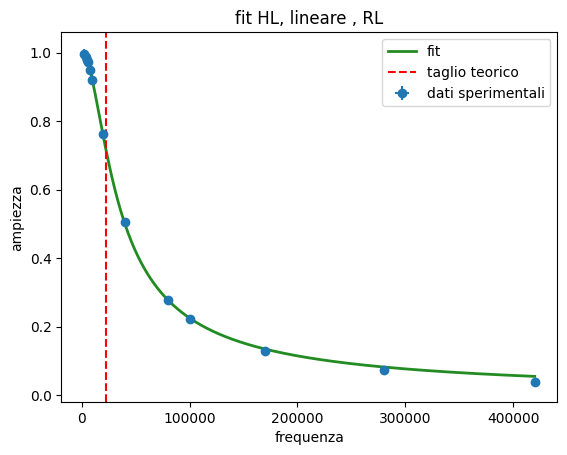

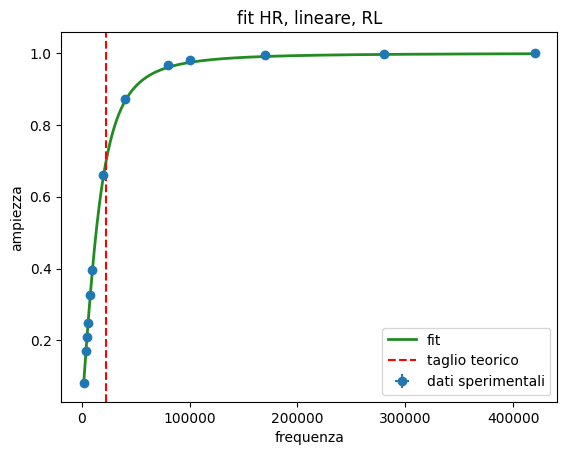

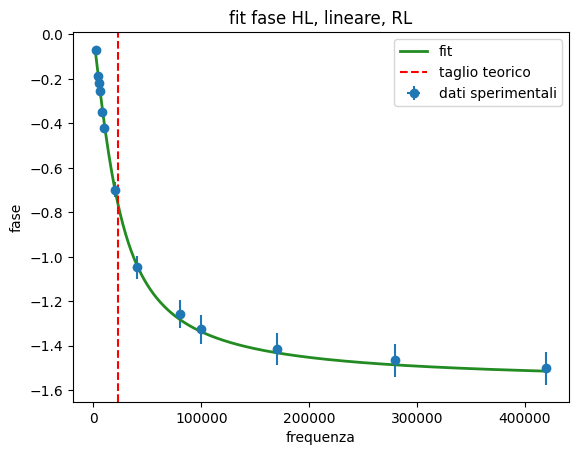

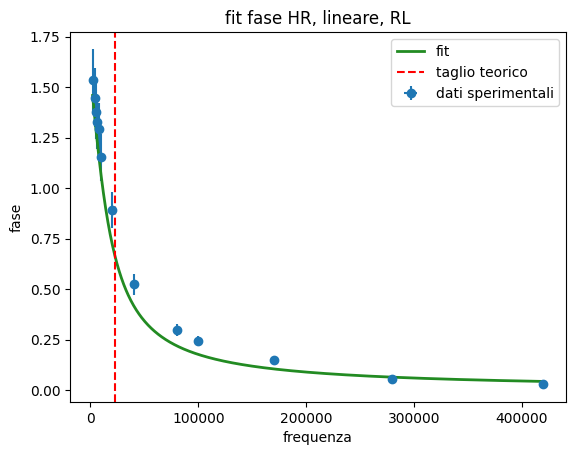

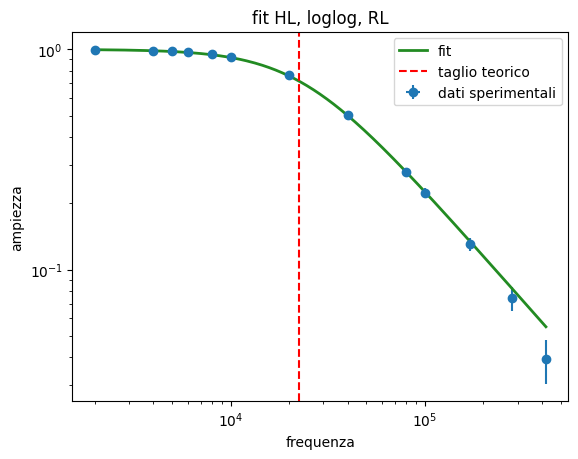

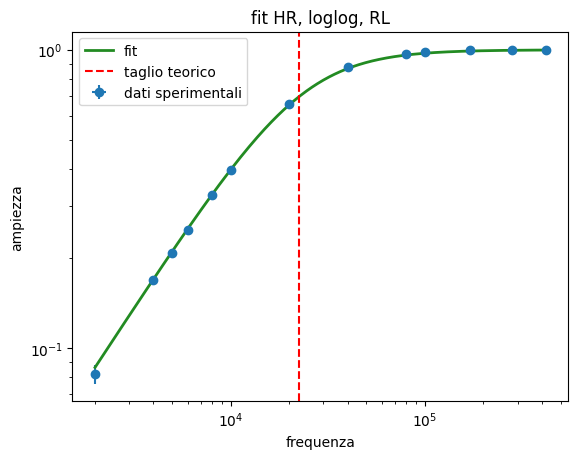

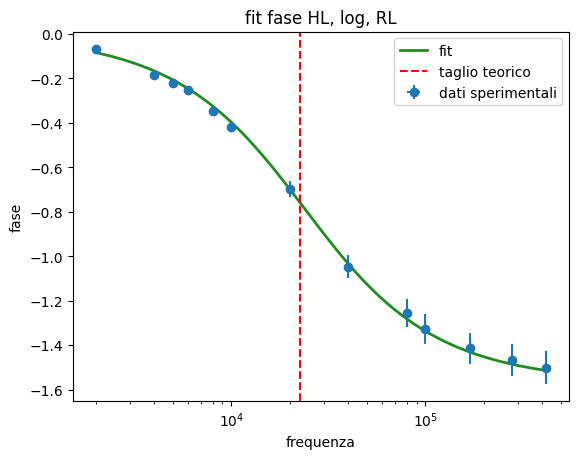

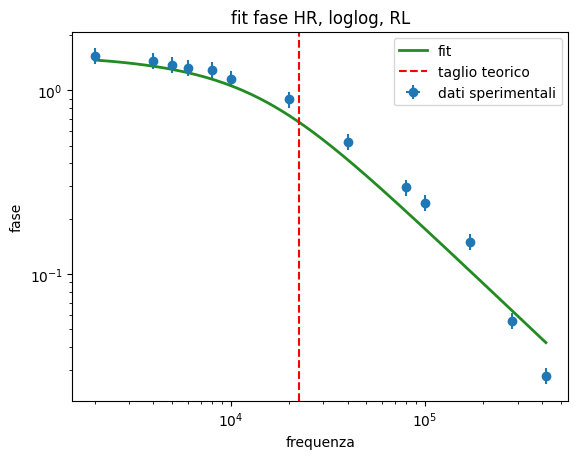

In [15]:
#fit lineari
#plot fit 1
plot_fit_ampiezza(Fl , HLl, errHLl ,HL , my_minuit1,f, "fit HL, lineare , RL")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)

#plot fit 2
plot_fit_ampiezza(Fl , HRl, errHRl ,HR , my_minuit2,f, "fit HR, lineare, RL")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)

#plot fit 3
plot_fit_fase(Fl , faseHL, np.abs(faseHL*(5/100)) ,argHL , my_minuit3,f, "fit fase HL, lineare, RL")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)

#plot fit 4
plot_fit_fase(Fl , faseHR, faseHR*(10/100) ,argHR , my_minuit4,f, "fit fase HR, lineare, RL")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)

#----------------------------------------------------------------------------------------------------------------
#fit log
#plot fit 1
plot_fit_ampiezza_log(Fl , HLl, errHLl ,HL , my_minuit1,f, "fit HL, loglog, RL")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)

#plot fit 2
plot_fit_ampiezza_log(Fl , HRl, errHRl ,HR , my_minuit2,f, "fit HR, loglog, RL")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)

#plot fit 3
plot_fit_fase_logx(Fl , faseHL, np.abs(faseHL*(5/100)), argHL , my_minuit3,f, "fit fase HL, log, RL")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)

#plot fit 4
plot_fit_fase_log(Fl , faseHR, faseHR*(10/100) ,argHR , my_minuit4,f, "fit fase HR, loglog, RL")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)

In [16]:
#parte 1 RC
tau_a= Ci*R_us
fc=(1/tau_a)/(2*np.pi)
print(tau_a)
print(fc)

6.937511610299588e-05
2294.1214664867775


In [17]:
#funzioni RC
k_att = R_us*Ci
def HC(f, k):
    a = 2 * np.pi * k
    return (f*a) / np.sqrt(1 + (f*a)**2)

def HRC(f, k):
    a = 2 * np.pi * k
    return 1 / np.sqrt(1 + (f*a)**2)

def argHC(f, k):
    a = 2 * np.pi * f * k
    return (np.pi / 2) - np.arctan(a)

def argHRc(f, k):
    a = 2 * np.pi * f * k
    return - np.arctan(a)
print(k_att)

6.937511610299588e-05


In [18]:
with open('C3RC.txt') as input_file:
    Fclist = []
    HCclist = [] #funzione traferimento C
    errHCclist = []
    HRclist = [] #funzione trasferimento R
    errHRclist = []
    argHCclist = []
    argHRclist = []
    for riga in input_file:
        valoriLC = riga.split()
        Fclist.append(float(valoriLC[0]))
        HCclist.append(float(valoriLC[1]))
        HRclist.append(float(valoriLC[2]))
        argHCclist.append(float(valoriLC[3]))
        argHRclist.append(float(valoriLC[4]))
        errHCclist.append(float(valoriLC[5]))
        errHRclist.append(float(valoriLC[6]))

faseHCclist = np.radians(argHCclist)
faseHRclist = np.radians(argHRclist)


Fc = Fclist
HCc = HCclist
errHCc = errHCclist
HRc = HRclist
errHRc = errHRclist
faseHRc = faseHRclist
faseHC = faseHCclist

Fc = np.array(Fclist)
HCc = np.array(HCclist)
errHCc = np.array(errHCc)
HRc = np.array(HRclist)
errHRc = np.array(errHRc)
faseHC = np.array(faseHCclist)
faseHRc = np.array(faseHRclist)

In [19]:
#fit con HC
least_squares = LeastSquares (Fc, HCc, errHCc, HC)
my_minuit5 = Minuit (least_squares, k=0.00000001)
my_minuit5.limits["k"] = (k_att-10e-3, k_att+10e-3)
my_minuit5.migrad ()
my_minuit5.hesse ()


is_valid = my_minuit5.valid
print ('success of the fit: ', is_valid)

Q_squared = my_minuit5.fval
print ('value of the fit Q-squared', Q_squared)
N_dof = my_minuit5.ndof
print ('value of the number of degrees of freedom', N_dof)

from scipy.stats import chi2
print ('associated p-value: ', 1. - chi2.cdf (my_minuit5.fval, df = my_minuit5.ndof))

for par, val, err in zip (my_minuit5.parameters, my_minuit5.values, my_minuit5.errors) :
    print(f'{par} = {val:.3f} +/- {err:.3f}') # formatted output

k_fit = my_minuit5.values[0]
erk = my_minuit5.errors[0]


print (my_minuit5.covariance)


display (my_minuit5)

success of the fit:  True
value of the fit Q-squared 4.47014857252009
value of the number of degrees of freedom 9.0
associated p-value:  0.8778402369690734
k = 0.000 +/- 0.000
┌───┬──────────┐
│   │        k │
├───┼──────────┤
│ k │ 1.77e-12 │
└───┴──────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 4.47 (χ²/ndof = 0.5)       │              Nfcn = 46               │
│ EDM = 3.4e-07 (Goal: 0.0002)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ k    │  70.4e-6  │  1.3e-6   │            │            │-0.00993062│0.0100694│       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬──────────┐
│   │        k │
├───┼──────────┤
│ k │ 1.77e-12 │
└───┴──────────┘

In [20]:
t_student_k= np.abs((k_att-k_fit)/erk)
print(k_fit, erk)
print(t_student_k)

7.043603919110013e-05 1.330842027004453e-06
0.7971818341897782


In [21]:
#fit con HRC
least_squares = LeastSquares (Fc, HRc, errHRc, HRC)
my_minuit6 = Minuit (least_squares, k=0.00000001)
my_minuit6.limits["k"] = (k_att-10e-3, k_att+10e-3)
my_minuit6.migrad ()
my_minuit6.hesse ()


is_valid = my_minuit6.valid
print ('success of the fit: ', is_valid)

Q_squared = my_minuit6.fval
print ('value of the fit Q-squared', Q_squared)
N_dof = my_minuit6.ndof
print ('value of the number of degrees of freedom', N_dof)

from scipy.stats import chi2
print ('associated p-value: ', 1. - chi2.cdf (my_minuit6.fval, df = my_minuit6.ndof))

for par, val, err in zip (my_minuit6.parameters, my_minuit6.values, my_minuit6.errors) :
    print(f'{par} = {val:.3f} +/- {err:.3f}') # formatted output

k_fit = my_minuit6.values[0]
erk = my_minuit6.errors[0]


print (my_minuit6.covariance)


display (my_minuit6)

success of the fit:  True
value of the fit Q-squared 4.891458782652445
value of the number of degrees of freedom 9.0
associated p-value:  0.8436655241142571
k = 0.000 +/- 0.000
┌───┬──────────┐
│   │        k │
├───┼──────────┤
│ k │ 8.99e-13 │
└───┴──────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 4.891 (χ²/ndof = 0.5)      │              Nfcn = 62               │
│ EDM = 2.45e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ k    │  68.2e-6  │  0.9e-6   │            │            │-0.00993062│0.0100694│       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬──────────┐
│   │        k │
├───┼──────────┤
│ k │ 8.99e-13 │
└───┴──────────┘

In [22]:
t_student_k= np.abs((k_att-k_fit)/erk)
print(k_fit, erk)
print(t_student_k)

6.818219075508877e-05 9.481037774481879e-07
1.2582223341814434


In [23]:
#fit con fase HC
least_squares = LeastSquares (Fc, faseHC, faseHC*(10/100) , argHC)
my_minuit7 = Minuit (least_squares, k=0.00000001)
my_minuit7.limits["k"] = (k_att-10e-3, k_att+10e-3)
my_minuit7.migrad ()
my_minuit7.hesse ()


is_valid = my_minuit7.valid
print ('success of the fit: ', is_valid)

Q_squared = my_minuit7.fval
print ('value of the fit Q-squared', Q_squared)
N_dof = my_minuit7.ndof
print ('value of the number of degrees of freedom', N_dof)

from scipy.stats import chi2
print ('associated p-value: ', 1. - chi2.cdf (my_minuit7.fval, df = my_minuit7.ndof))

for par, val, err in zip (my_minuit7.parameters, my_minuit7.values, my_minuit7.errors) :
    print(f'{par} = {val:.3f} +/- {err:.3f}') # formatted output

k_fit = my_minuit7.values[0]
erk = my_minuit7.errors[0]


print (my_minuit7.covariance)


display (my_minuit7)

success of the fit:  True
value of the fit Q-squared 34.44941631982177
value of the number of degrees of freedom 9.0
associated p-value:  7.448594718384438e-05
k = 0.000 +/- 0.000
┌───┬──────────┐
│   │        k │
├───┼──────────┤
│ k │ 1.21e-11 │
└───┴──────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 34.45 (χ²/ndof = 3.8)      │              Nfcn = 65               │
│ EDM = 3.86e-09 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ k    │  79.0e-6  │  3.5e-6   │            │            │-0.00993062│0.0100694│       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬──────────┐
│   │        k │
├───┼──────────┤
│ k │ 1.21e-11 │
└───┴──────────┘

In [24]:
t_student_k= np.abs((k_att-k_fit)/erk)
print(k_fit, erk)
print(t_student_k)

7.897362909118147e-05 3.4780247614588436e-06
2.7597598195820594


In [25]:
#fit con fase HC
least_squares = LeastSquares (Fc, faseHRc, faseHRc*(5/100) , argHRc)
my_minuit8 = Minuit (least_squares, k=0.00000001)
my_minuit8.limits["k"] = (k_att-10e-3, k_att+10e-3)
my_minuit8.migrad ()
my_minuit8.hesse ()


is_valid = my_minuit8.valid
print ('success of the fit: ', is_valid)

Q_squared = my_minuit8.fval
print ('value of the fit Q-squared', Q_squared)
N_dof = my_minuit8.ndof
print ('value of the number of degrees of freedom', N_dof)

from scipy.stats import chi2
print ('associated p-value: ', 1. - chi2.cdf (my_minuit8.fval, df = my_minuit8.ndof))

for par, val, err in zip (my_minuit8.parameters, my_minuit8.values, my_minuit8.errors) :
    print(f'{par} = {val:.3f} +/- {err:.3f}') # formatted output

k_fit = my_minuit8.values[0]
erk = my_minuit8.errors[0]


print (my_minuit8.covariance)


display (my_minuit8)

success of the fit:  True
value of the fit Q-squared 12.697072196730744
value of the number of degrees of freedom 9.0
associated p-value:  0.17679926553039615
k = 0.000 +/- 0.000
┌───┬──────────┐
│   │        k │
├───┼──────────┤
│ k │ 2.76e-12 │
└───┴──────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 12.7 (χ²/ndof = 1.4)       │              Nfcn = 38               │
│ EDM = 4.79e-07 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ k    │  69.7e-6  │  1.7e-6   │            │            │-0.00993062│0.0100694│       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬──────────┐
│   │        k │
├───┼──────────┤
│ k │ 2.76e-12 │
└───┴──────────┘

In [26]:
t_student_k= np.abs((k_att-k_fit)/erk)
print(k_fit, erk)
print(t_student_k)

6.9712677605447e-05 1.660572131931791e-06
0.2032802405628886


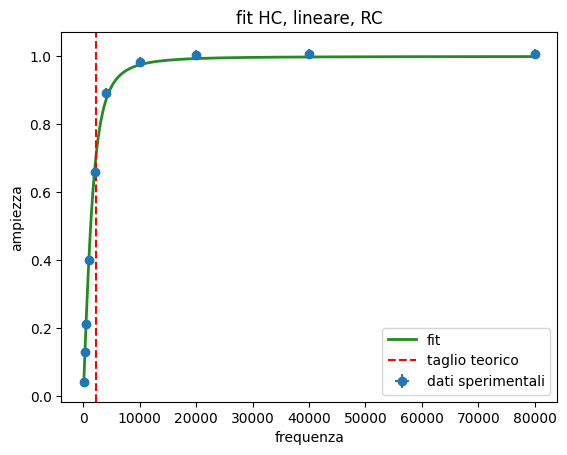

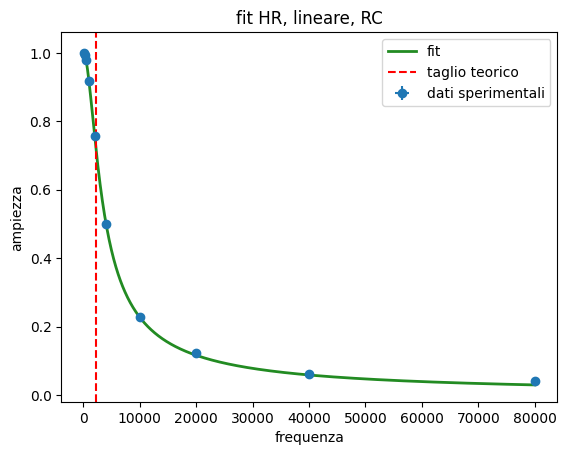

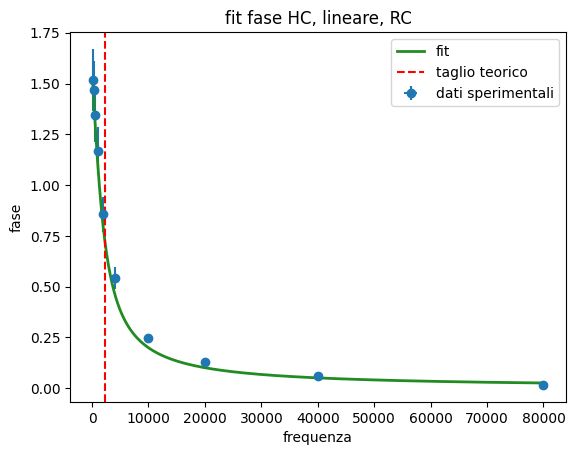

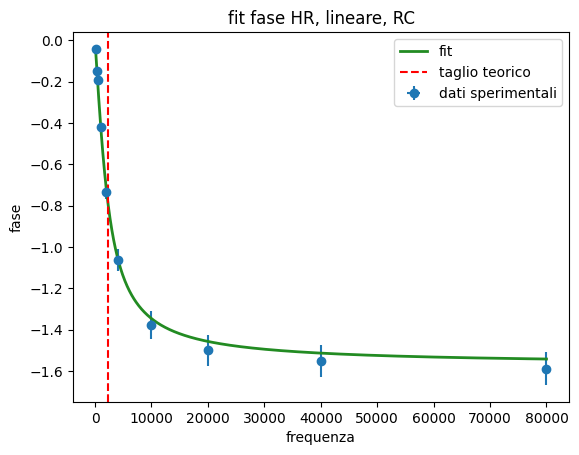

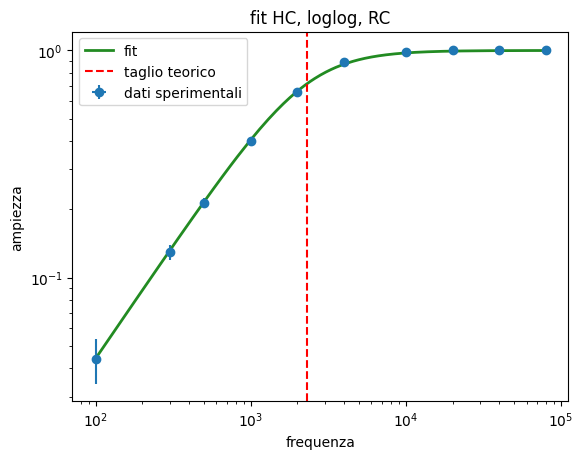

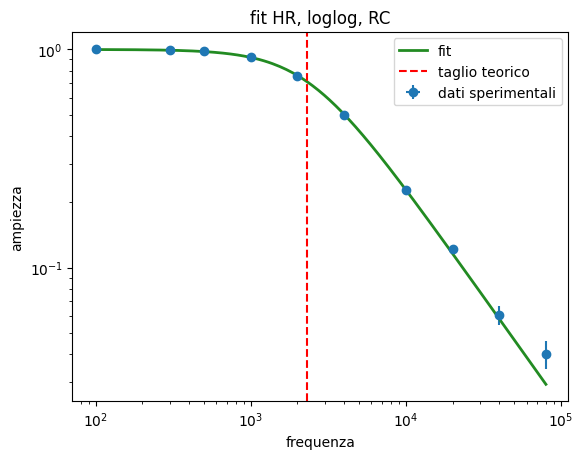

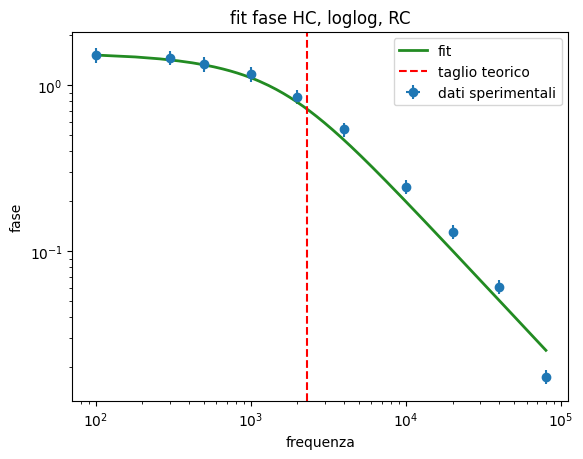

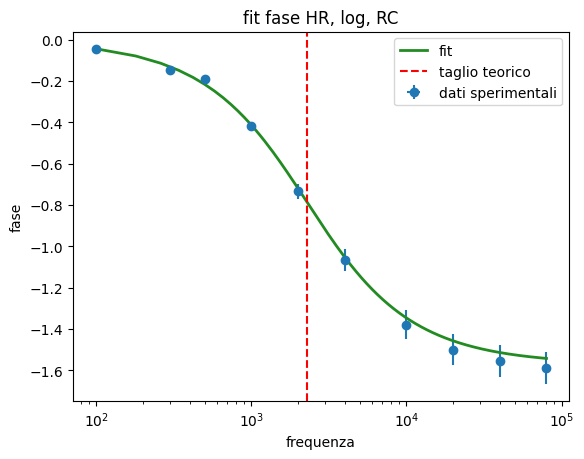

In [27]:
#plot fit 1
plot_fit_ampiezza(Fc , HCc, errHCc ,HC , my_minuit5,fc, "fit HC, lineare, RC")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)

#plot fit 2
plot_fit_ampiezza(Fc , HRc, errHRc ,HRC , my_minuit6,fc, "fit HR, lineare, RC")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)

#plot fit 3
plot_fit_fase(Fc , faseHC, np.abs(faseHC*(10/100)) ,argHC , my_minuit7,fc, "fit fase HC, lineare, RC")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)

#plot fit 4
plot_fit_fase(Fc , faseHRc, np.abs(faseHRc*(5/100)) ,argHRc , my_minuit8,fc, "fit fase HR, lineare, RC")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)

#----------------------------------------------------------------------------------------------------------------------------
#log fit
#plot fit 1
plot_fit_ampiezza_log(Fc , HCc, errHCc ,HC , my_minuit5,fc, "fit HC, loglog, RC")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)

#plot fit 2
plot_fit_ampiezza_log(Fc , HRc, errHRc ,HRC , my_minuit6,fc, "fit HR, loglog, RC")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)

#plot fit 3
plot_fit_fase_log(Fc , faseHC, np.abs(faseHC*(10/100)) ,argHC , my_minuit7,fc, "fit fase HC, loglog, RC")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)

#plot fit 4
plot_fit_fase_logx(Fc , faseHRc, np.abs(faseHRc*(5/100)) ,argHRc , my_minuit8,fc, "fit fase HR, log, RC")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)

In [28]:
#parte 2 RLC
#regime sovrasmorzato
Rrlc_sovrasmorzato=1350
Rcritico1= 2*np.sqrt(Li1/Ci)
Rcritico2= 2*np.sqrt(Li2/Ci)


print(Rcritico1, Rcritico2)

430.2242199432305 426.14617321528283


In [29]:
#retta di inversione
frlc1=1/(2*np.pi*np.sqrt(Li1*Ci))
frlc2=1/(2*np.pi*np.sqrt(Li2*Ci))
print(frlc1, frlc2)

7177.391115494749 7246.075849028559


In [30]:
#formule RLC
R = Rrlc_sovrasmorzato
def HRrlc(frlc1, L, C):
    w = 2 * np.pi * frlc1
    return R / np.sqrt(R**2 + (w*L - 1/(w*C))**2)

def HCrlC(frlc2, L, C):
    w = 2 * np.pi * frlc2
    return 1 / np.sqrt((1 - w**2 * L * C)**2 + (w * R * C)**2)

def HLrlc(frlc1, L, C):
    w = 2 * np.pi * frlc1
    return (w * L) / np.sqrt((R+Rl)**2 + (w*L - 1/(w*C))**2)

def argHRrlc(frlc1, L, C):
    w = 2 * np.pi * frlc1
    return -np.degrees(np.arctan2(w*L - 1/(w*C), R))

def argHCrlc(frlc2, L, C):
    w = 2 * np.pi * frlc2
    return -np.degrees(np.arctan2(w * R * C, 1 - w**2 * L * C))

def argHLrlc(frlc1, L, C):
    w = 2 * np.pi * frlc1
    return 90 - np.degrees(np.arctan2(w*L - 1/(w*C), R))

In [31]:
#parte HR campana
with open('C3RLC_R.txt') as input_file:
    FRlclist = []
    HRlclist = []
    errHRlclist = []
    faseHRrlclist = []
    for riga in input_file:
        valoriLC = riga.split()
        FRlclist.append(float(valoriLC[0]))
        HRlclist.append(float(valoriLC[1]))
        errHRlclist.append(float(valoriLC[2]))
        faseHRrlclist.append(float(valoriLC[3]))

FRlc = FRlclist
HRlc = HRlclist
errHRlc = errHRlclist
#faseHRrlcrad = np.radians(faseHRrlclist)


FRlc = np.array(FRlclist)
HRlc = np.array(HRlclist)
errHRlc = np.array(errHRlclist)
faseHRlc= np.array(faseHRrlclist)

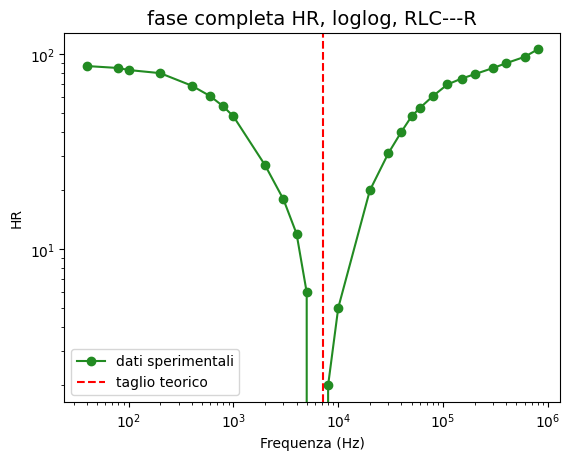

In [32]:
#grafico log HR
fig, ax = plt.subplots ()
plt.plot(FRlc, np.abs(faseHRlc), 'o-', color='forestgreen', label='dati sperimentali')
ax.set_title ('fase completa HR, loglog, RLC---R', size=14)
ax.set_ylabel ('HR')
ax.set_xlabel ('Frequenza (Hz)')
plt.axvline(x = frlc1, linestyle = '--', color = 'red', label= 'taglio teorico')
plt.xscale('log')
plt.yscale('log')
#ax.scatter(Freq, HL)
#ax.errorbar (Freq, HL, xerr = 0.0, yerr = 0.0, linestyle = 'None',marker = 'o')
#plt.savefig("aaa.png")
ax.legend()
plt.show()
#plt.close(fig)

In [33]:
#fit con HR---RLC ampiezza
least_squares = LeastSquares (FRlc, HRlc, errHRlc, HRrlc)
my_minuit9 = Minuit (least_squares, L=0.00001, C=0.000000000001)
my_minuit9.limits["L"] = (0.003, 0.006)
my_minuit9.limits["C"] = (Ci-10e-6, Ci+10e-6)
my_minuit9.migrad ()
my_minuit9.hesse ()


is_valid = my_minuit9.valid
print ('success of the fit: ', is_valid)

Q_squared = my_minuit9.fval
print ('value of the fit Q-squared', Q_squared)
N_dof = my_minuit9.ndof
print ('value of the number of degrees of freedom', N_dof)

from scipy.stats import chi2
print ('associated p-value: ', 1. - chi2.cdf (my_minuit9.fval, df = my_minuit9.ndof))

for par, val, err in zip (my_minuit9.parameters, my_minuit9.values, my_minuit9.errors) :
    print(f'{par} = {val:.3f} +/- {err:.3f}') # formatted output

L_fit = my_minuit9.values[0]
erL = my_minuit9.errors[0]
C_fit = my_minuit9.values[1]
erC = my_minuit9.errors[1]



print (my_minuit9.covariance)


display (my_minuit9)

success of the fit:  True
value of the fit Q-squared 85.17371073689691
value of the number of degrees of freedom 26.0
associated p-value:  3.268689641178213e-08
L = 0.005 +/- 0.000
C = 0.000 +/- 0.000
┌───┬─────────────────────────┐
│   │           L           C │
├───┼─────────────────────────┤
│ L │    2.75e-09 -2.5730e-15 │
│ C │ -2.5730e-15    2.17e-18 │
└───┴─────────────────────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 85.17 (χ²/ndof = 3.3)      │              Nfcn = 195              │
│ EDM = 1.29e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ L    │  4.63e-3  │  0.05e-3  │            │            │  0.003  │  0.006  │       │
│ 1 │ C    │ 102.4e-9  │  1.5e-9   │            │            │-9.89692e-06│1.01031e-05│       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬─────────────────────────┐
│   │           L           C │
├───┼─────────────────────────┤
│ L │    2.75e-09 -2.5730e-15 │
│ C │ -2.5730e-15    2.17e-18 │
└───┴─────────────────────────┘

In [34]:
print(L_fit, erL, C_fit ,erC)
t_student_L= np.abs((L_fit-Li1)/erL)
t_student_C=np.abs((C_fit-Ci)/erC)
print(t_student_L, t_student_C)

0.004625584058615923 5.246853256512954e-05 1.0236589285204951e-07 1.47372171716138e-09
2.7524295863394364 0.4868552623261854


In [35]:
#fit con HR---RLC fase
#divido i fit in 2: prima di 0, dopo lo 0, 0 escluso

In [36]:
#fit parte positiva
faseHRlcpos = faseHRlc[0:12]
FRlcpos = FRlc[0:12]

least_squares = LeastSquares (FRlcpos, faseHRlcpos, faseHRlcpos*(5/100), argHRrlc)
my_minuit10 = Minuit (least_squares, L=0.00001, C=0.000000000001)
my_minuit10.limits["L"] = (Li1-10e-1, Li1+10e-1)
my_minuit10.limits["C"] = (Ci-10e-6, Ci+10e-6)
my_minuit10.migrad ()
my_minuit10.hesse ()


is_valid = my_minuit10.valid
print ('success of the fit: ', is_valid)

Q_squared = my_minuit10.fval
print ('value of the fit Q-squared', Q_squared)
N_dof = my_minuit10.ndof
print ('value of the number of degrees of freedom', N_dof)

from scipy.stats import chi2
print ('associated p-value: ', 1. - chi2.cdf (my_minuit10.fval, df = my_minuit10.ndof))

for par, val, err in zip (my_minuit10.parameters, my_minuit10.values, my_minuit10.errors) :
    print(f'{par} = {val:.3f} +/- {err:.3f}') # formatted output

L_fitpos = my_minuit10.values[0]
erL_pos = my_minuit10.errors[0]
C_fitpos = my_minuit10.values[1]
erC_pos = my_minuit10.errors[1]


print (my_minuit10.covariance)


display (my_minuit10)

success of the fit:  True
value of the fit Q-squared 6.342764175534735
value of the number of degrees of freedom 10.0
associated p-value:  0.7856906947973841
L = 0.005 +/- 0.000
C = 0.000 +/- 0.000
┌───┬─────────────────────────────┐
│   │             L             C │
├───┼─────────────────────────────┤
│ L │      2.06e-07 -1.438855e-12 │
│ C │ -1.438855e-12      1.27e-17 │
└───┴─────────────────────────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 6.343 (χ²/ndof = 0.6)      │              Nfcn = 96               │
│ EDM = 2.1e-07 (Goal: 0.0002)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ L    │  5.3e-3   │  0.5e-3   │            │            │-0.99523 │ 1.00477 │       │
│ 1 │ C    │  101e-9   │   4e-9    │            │            │-9.89692e-06│1.01031e-05│       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬─────────────────────────────┐
│   │             L             C │
├───┼─────────────────────────────┤
│ L │      2.06e-07 -1.438855e-12 │
│ C │ -1.438855e-12      1.27e-17 │
└───┴─────────────────────────────┘

In [37]:
#fit parte negativa
faseHRlcneg = faseHRlc[13:28]
FRlcneg = FRlc[13:28]

least_squares = LeastSquares (FRlcneg, faseHRlcneg, faseHRlcneg*(5/100), argHRrlc)
my_minuit11 = Minuit (least_squares, L=0.00001, C=0.000000000001)
my_minuit11.limits["L"] = (Li1-10e-1, Li1+10e-1)
my_minuit11.limits["C"] = (Ci-10e-6, Ci+10e-6)
my_minuit11.migrad ()
my_minuit11.hesse ()


is_valid = my_minuit11.valid
print ('success of the fit: ', is_valid)

Q_squared = my_minuit11.fval
print ('value of the fit Q-squared', Q_squared)
N_dof = my_minuit11.ndof
print ('value of the number of degrees of freedom', N_dof)

from scipy.stats import chi2
print ('associated p-value: ', 1. - chi2.cdf (my_minuit11.fval, df = my_minuit11.ndof))

for par, val, err in zip (my_minuit11.parameters, my_minuit11.values, my_minuit11.errors) :
    print(f'{par} = {val:.3f} +/- {err:.3f}') # formatted output


L_fitneg = my_minuit11.values[0]
erL_neg = my_minuit11.errors[0]
C_fitneg = my_minuit11.values[1]
erC_neg = my_minuit11.errors[1]

print (my_minuit11.covariance)


display (my_minuit11)

success of the fit:  True
value of the fit Q-squared 38.13449720982123
value of the number of degrees of freedom 13.0
associated p-value:  0.00027449649696653644
L = 0.004 +/- 0.000
C = 0.000 +/- 0.000
┌───┬───────────────────────────┐
│   │            L            C │
├───┼───────────────────────────┤
│ L │     1.36e-08 -439.060e-15 │
│ C │ -439.060e-15     1.61e-17 │
└───┴───────────────────────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 38.13 (χ²/ndof = 2.9)      │              Nfcn = 383              │
│ EDM = 1.14e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ L    │  4.49e-3  │  0.12e-3  │            │            │-0.99523 │ 1.00477 │       │
│ 1 │ C    │  110e-9   │   4e-9    │            │            │-9.89692e-06│1.01031e-05│       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬───────────────────────────┐
│   │            L            C │
├───┼───────────────────────────┤
│ L │     1.36e-08 -439.060e-15 │
│ C │ -439.060e-15     1.61e-17 │
└───┴───────────────────────────┘

In [38]:
print('fit parte positiva')
print(L_fitpos, erL_pos, C_fitpos ,erC_pos)
t_student_L_pos= np.abs((L_fitpos-Li1)/erL_pos)
t_student_C_pos=np.abs((C_fitpos-Ci)/erC_pos)
print(t_student_L_pos, t_student_C_pos)

print('fit parte negativa')
print(L_fitneg, erL_neg, C_fitneg ,erC_neg)
t_student_L_neg= np.abs((L_fitneg-Li1)/erL_neg)
t_student_C_neg=np.abs((C_fitneg-Ci)/erC_neg)
print(t_student_L_neg, t_student_C_neg)

fit parte positiva
0.005297947391976421 0.0004543349377860162 1.0137569304785844e-07 3.5647456823237583e-09
1.1620224377837192 0.47904931503620657
fit parte negativa
0.004493432526611385 0.00011654120538495683 1.098351016534414e-07 4.006274298130164e-09
2.373130365994261 1.6852864097045714


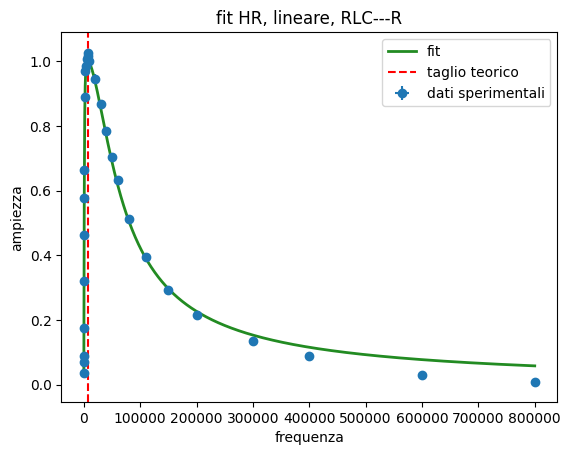

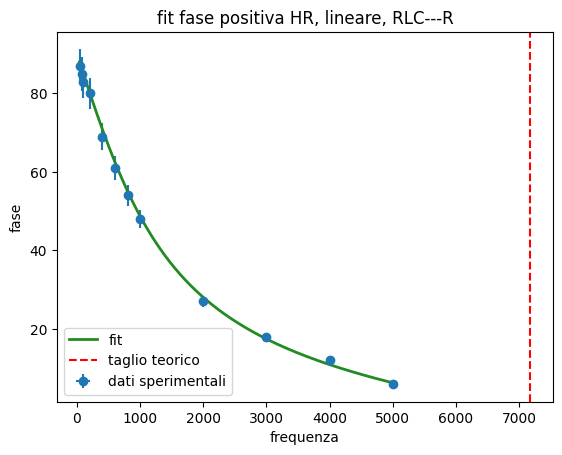

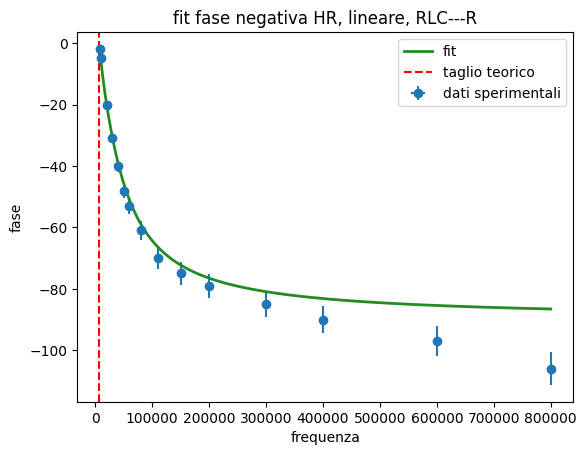

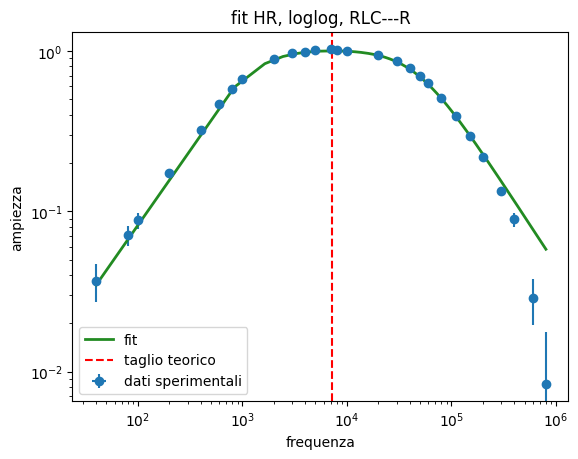

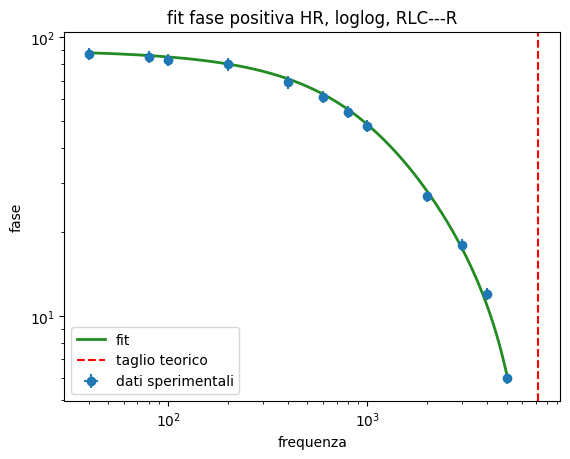

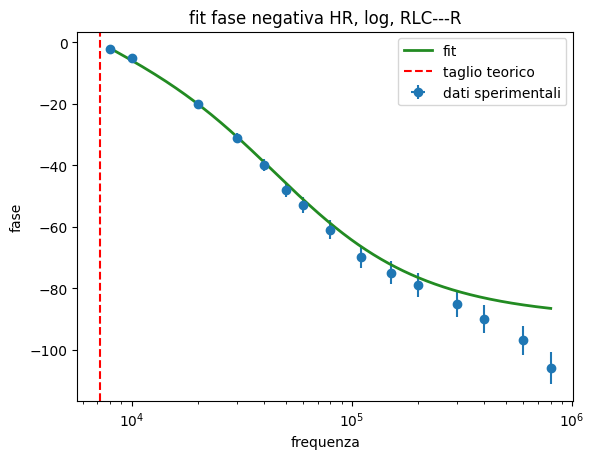

In [39]:
#plot fit 1 ampiezza
plot_fit_ampiezza(FRlc , HRlc, errHRlc , HRrlc , my_minuit9,frlc1, "fit HR, lineare, RLC---R")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)

#plot fit 2 fase positiva
plot_fit_fase(FRlcpos , faseHRlcpos, np.abs(faseHRlcpos*(5/100)) ,argHRrlc , my_minuit10, frlc1, "fit fase positiva HR, lineare, RLC---R")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)

#plot fit 3 fase negativa
plot_fit_fase(FRlcneg , faseHRlcneg, np.abs(faseHRlcneg*(5/100)) ,argHRrlc , my_minuit11, frlc1, "fit fase negativa HR, lineare, RLC---R")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)

#--------------------------------------------------------------------------------------------------------------------------
#log fit
#plot fit 1 ampiezza
plot_fit_ampiezza_log(FRlc , HRlc, errHRlc , HRrlc , my_minuit9, frlc1, "fit HR, loglog, RLC---R")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)

#plot fit 2 fase positiva
plot_fit_fase_log(FRlcpos , faseHRlcpos, np.abs(faseHRlcpos*(5/100)) ,argHRrlc , my_minuit10, frlc1, "fit fase positiva HR, loglog, RLC---R")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)

#plot fit 3 fase negativa
plot_fit_fase_logx(FRlcneg , faseHRlcneg, np.abs(faseHRlcneg*(5/100)) ,argHRrlc , my_minuit11, frlc1, "fit fase negativa HR, log, RLC---R")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)

In [40]:
#parte HL passa alto
with open('C3RLC_L.txt') as input_file:
    FrLclist = []
    HLrlclist = []
    faseHLrlclist = []
    errHLrlclist = []
    for riga in input_file:
        valoriLC = riga.split()
        FrLclist.append(float(valoriLC[0]))
        HLrlclist.append(float(valoriLC[1]))
        errHLrlclist.append(float(valoriLC[2]))
        faseHLrlclist.append(float(valoriLC[3]))

FLrlc = FrLclist
HLrLc = HLrlclist
faseHLrlc = faseHLrlclist
errHLrlc = errHLrlclist

FrLc = np.array(FLrlc)
HLrLc = np.array(HLrLc)
faseHLrlc = np.array(faseHLrlc)
errHLrlc = np.array(errHLrlc)

In [41]:
#fit con HL---RLC ampiezza
least_squares = LeastSquares (FrLc, HLrLc, errHLrlc, HLrlc)
my_minuit12 = Minuit (least_squares, L=0.004, C=10e-8)
my_minuit12.limits["L"] = (0.0039, 0.005)
my_minuit12.limits["C"] = (Ci-10e-8, Ci+10e-8)
my_minuit12.migrad ()
my_minuit12.hesse ()


is_valid = my_minuit12.valid
print ('success of the fit: ', is_valid)

Q_squared = my_minuit12.fval
print ('value of the fit Q-squared', Q_squared)
N_dof = my_minuit12.ndof
print ('value of the number of degrees of freedom', N_dof)

from scipy.stats import chi2
print ('associated p-value: ', 1. - chi2.cdf (my_minuit12.fval, df = my_minuit12.ndof))

for par, val, err in zip (my_minuit12.parameters, my_minuit12.values, my_minuit12.errors) :
    print(f'{par} = {val:.3f} +/- {err:.3f}') # formatted output

L_fit = my_minuit12.values[0]
erL = my_minuit12.errors[0]
C_fit = my_minuit12.values[1]
erC = my_minuit12.errors[1]



print (my_minuit12.covariance)


display (my_minuit12)

success of the fit:  True
value of the fit Q-squared 9.215787815969598
value of the number of degrees of freedom 11.0
associated p-value:  0.6019816419019017
L = 0.005 +/- 0.000
C = 0.000 +/- 0.000
┌───┬─────────────────────────┐
│   │           L           C │
├───┼─────────────────────────┤
│ L │    1.45e-08 1.68310e-12 │
│ C │ 1.68310e-12    2.51e-16 │
└───┴─────────────────────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 9.216 (χ²/ndof = 0.8)      │              Nfcn = 100              │
│ EDM = 7.06e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ L    │  4.79e-3  │  0.12e-3  │            │            │ 0.0039  │  0.005  │       │
│ 1 │ C    │ 0.036e-6  │ 0.016e-6  │            │            │3.08338e-09│2.03083e-07│       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬─────────────────────────┐
│   │           L           C │
├───┼─────────────────────────┤
│ L │    1.45e-08 1.68310e-12 │
│ C │ 1.68310e-12    2.51e-16 │
└───┴─────────────────────────┘

In [42]:
print(L_fit, erL, C_fit ,erC)
t_student_L= np.abs((L_fit-Li1)/erL)
t_student_C=np.abs((C_fit-Ci)/erC)
print(t_student_L, t_student_C)

0.00478866373071684 0.00011896712488249864 3.5685437955346156e-08 1.572454772748692e-08
0.15688141354406612 4.286161054546223


In [43]:
#fit con HL---RLC fase
least_squares = LeastSquares (FrLc, faseHLrlc, faseHLrlc*(5/100), argHLrlc)
my_minuit13 = Minuit (least_squares, L=0.00004, C=0.000000001)
my_minuit13.limits["L"] = (Li1-10e-3,Li1 +10e-3)
my_minuit13.limits["C"] = (Ci-10e-7, Ci+10e-7)
my_minuit13.migrad ()
my_minuit13.hesse ()


is_valid = my_minuit13.valid
print ('success of the fit: ', is_valid)

Q_squared = my_minuit13.fval
print ('value of the fit Q-squared', Q_squared)
N_dof = my_minuit13.ndof
print ('value of the number of degrees of freedom', N_dof)

from scipy.stats import chi2
print ('associated p-value: ', 1. - chi2.cdf (my_minuit13.fval, df = my_minuit13.ndof))

for par, val, err in zip (my_minuit13.parameters, my_minuit13.values, my_minuit13.errors) :
    print(f'{par} = {val:.3f} +/- {err:.3f}') # formatted output

L_fit = my_minuit13.values[0]
erL = my_minuit13.errors[0]
C_fit = my_minuit13.values[1]
erC = my_minuit13.errors[1]



print (my_minuit13.covariance)


display (my_minuit13)

success of the fit:  True
value of the fit Q-squared 6.875681680441044
value of the number of degrees of freedom 11.0
associated p-value:  0.8090598109448712
L = 0.005 +/- 0.000
C = 0.000 +/- 0.000
┌───┬───────────────────────┐
│   │          L          C │
├───┼───────────────────────┤
│ L │   9.93e-09 -850.9e-15 │
│ C │ -850.9e-15   7.94e-16 │
└───┴───────────────────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 6.876 (χ²/ndof = 0.6)      │              Nfcn = 209              │
│ EDM = 2.22e-06 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ L    │  5.17e-3  │  0.10e-3  │            │            │-0.00523 │ 0.01477 │       │
│ 1 │ C    │ 0.079e-6  │ 0.028e-6  │            │            │-8.96917e-07│1.10308e-06│       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬───────────────────────┐
│   │          L          C │
├───┼───────────────────────┤
│ L │   9.93e-09 -850.9e-15 │
│ C │ -850.9e-15   7.94e-16 │
└───┴───────────────────────┘

In [44]:
print(L_fit, erL, C_fit ,erC)
t_student_L= np.abs((L_fit-Li1)/erL)
t_student_C= np.abs((C_fit-Ci)/erC)
print(t_student_L, t_student_C)

0.005174126520318517 9.965661561101014e-05 7.914234776675211e-08 2.8167306110206333e-08
4.055190092908079 0.8499582517700136


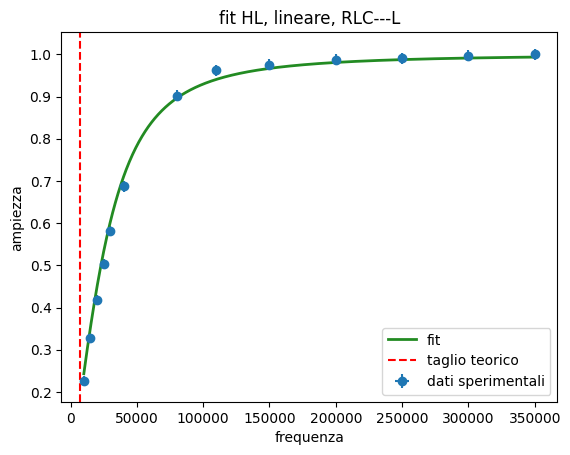

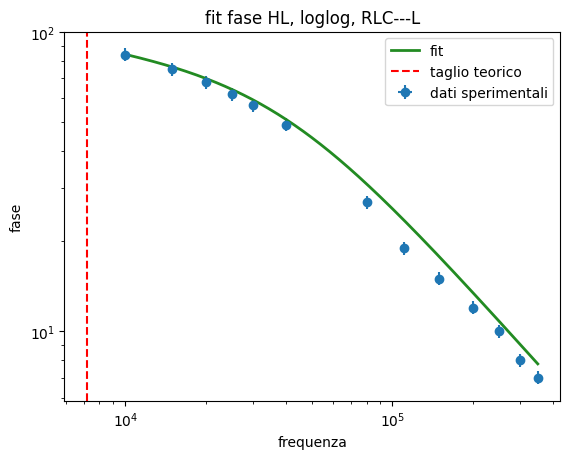

In [45]:
#plot fit 1 ampiezza
plot_fit_ampiezza(FrLc , HLrLc, errHLrlc , HLrlc , my_minuit10, frlc1, "fit HL, lineare, RLC---L")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)

#plot fit 2 fase
plot_fit_fase_log(FrLc , faseHLrlc, (faseHLrlc*(5/100)) ,argHLrlc , my_minuit11, frlc1, "fit fase HL, loglog, RLC---L")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)


In [46]:
#parte HC passa basso
#L rotta abbiamo dovuto cambiarla, potrebbe essere leggermente diverso il fit
with open('C3RLC_C.txt') as input_file:
    FrlClist = []
    HLrlClist = []
    faseHCrlclist = []
    errHCrlclist = []
    for riga in input_file:
        valoriLC = riga.split()
        FrlClist.append(float(valoriLC[0]))
        HLrlClist.append(float(valoriLC[1]))
        faseHCrlclist.append(float(valoriLC[2]))
        errHCrlclist.append(float(valoriLC[3]))
FCrlc = FrlClist
HCrlc = HLrlClist
faseHCrlc = faseHCrlclist
errHCrlc = errHCrlclist

FrlC = np.array(FrlClist)
HCrlc = np.array(HLrlClist)
faseHCrlc = np.array(faseHCrlc)
errHCrlc = np.array(errHCrlc)


In [47]:
#fit con HC---RLC ampiezza
least_squares = LeastSquares (FrlC, HCrlc, errHCrlc, HCrlC)
my_minuit14 = Minuit (least_squares, L=0.0004, C=0.00000000001)
my_minuit14.limits["L"] = (Li1-10e-4,Li1 +10e-4)
my_minuit14.limits["C"] = (Ci-10e-8, Ci+10e-8)
my_minuit14.migrad ()
my_minuit14.hesse ()


is_valid = my_minuit14.valid
print ('success of the fit: ', is_valid)

Q_squared = my_minuit14.fval
print ('value of the fit Q-squared', Q_squared)
N_dof = my_minuit14.ndof
print ('value of the number of degrees of freedom', N_dof)

from scipy.stats import chi2
print ('associated p-value: ', 1. - chi2.cdf (my_minuit14.fval, df = my_minuit14.ndof))

for par, val, err in zip (my_minuit14.parameters, my_minuit14.values, my_minuit14.errors) :
    print(f'{par} = {val:.3f} +/- {err:.3f}') # formatted output

L_fit = my_minuit14.values[0]
erL = my_minuit14.errors[0]
C_fit = my_minuit14.values[1]
erC = my_minuit14.errors[1]



print (my_minuit14.covariance)


display (my_minuit14)

success of the fit:  True
value of the fit Q-squared 2.1036924227071996
value of the number of degrees of freedom 13.0
associated p-value:  0.9996993201460102
L = 0.004 +/- 0.002
C = 0.000 +/- 0.000
┌───┬───────────────────┐
│   │        L        C │
├───┼───────────────────┤
│ L │ 7.79e-24   -0e-24 │
│ C │   -0e-24 2.15e-18 │
└───┴───────────────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.104 (χ²/ndof = 0.2)      │              Nfcn = 64               │
│ EDM = 4.95e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ L    │  0.0038   │  0.0018   │            │            │ 0.00377 │ 0.00577 │       │
│ 1 │ C    │ 102.4e-9  │  1.5e-9   │            │            │3.08338e-09│2.03083e-07│       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬───────────────────┐
│   │        L        C │
├───┼───────────────────┤
│ L │ 7.79e-24   -0e-24 │
│ C │   -0e-24 2.15e-18 │
└───┴───────────────────┘

In [48]:
print(L_fit, erL, C_fit ,erC)
t_student_L= np.abs((L_fit-Li2)/erL)
t_student_C=np.abs((C_fit-Ci)/erC)
print(t_student_L, t_student_C)

0.00377 0.0018381910859527153 1.0236368295972057e-07 1.464821628083784e-09
0.4950519056229438 0.4913219819636465


In [49]:
#fit con HC---RLC fase
least_squares = LeastSquares (FrlC, faseHCrlc, faseHCrlc*(7/100), argHCrlc)
my_minuit15 = Minuit (least_squares, L=0.000001, C=0.000000000001)
my_minuit15.limits["L"] = (Li1-10e-1,Li1 +10e-1)
my_minuit15.limits["C"] = (Ci-10e-6, Ci+10e-6)
my_minuit15.migrad ()
my_minuit15.hesse ()


is_valid = my_minuit15.valid
print ('success of the fit: ', is_valid)

Q_squared = my_minuit15.fval
print ('value of the fit Q-squared', Q_squared)
N_dof = my_minuit15.ndof
print ('value of the number of degrees of freedom', N_dof)

from scipy.stats import chi2
print ('associated p-value: ', 1. - chi2.cdf (my_minuit15.fval, df = my_minuit15.ndof))

for par, val, err in zip (my_minuit15.parameters, my_minuit15.values, my_minuit15.errors) :
    print(f'{par} = {val:.3f} +/- {err:.3f}') # formatted output

L_fit = my_minuit15.values[0]
erL = my_minuit15.errors[0]
C_fit = my_minuit15.values[1]
erC = my_minuit15.errors[1]



print (my_minuit15.covariance)


display (my_minuit15)

success of the fit:  True
value of the fit Q-squared 93.73677128983506
value of the number of degrees of freedom 13.0
associated p-value:  2.6867397195928788e-14
L = 0.004 +/- 0.001
C = 0.000 +/- 0.000
┌───┬───────────────────────────┐
│   │            L            C │
├───┼───────────────────────────┤
│ L │      9.6e-07 -312.937e-15 │
│ C │ -312.937e-15     9.59e-18 │
└───┴───────────────────────────┘


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 93.74 (χ²/ndof = 7.2)      │              Nfcn = 103              │
│ EDM = 9.63e-09 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ L    │  3.5e-3   │  1.0e-3   │            │            │-0.99523 │ 1.00477 │       │
│ 1 │ C    │ 114.5e-9  │  3.1e-9   │            │            │-9.89692e-06│1.01031e-05│       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌───┬───────────────────────────┐
│   │            L            C │
├───┼───────────────────────────┤
│ L │      9.6e-07 -312.937e-15 │
│ C │ -312.937e-15     9.59e-18 │
└───┴───────────────────────────┘

In [50]:
print(L_fit, erL, C_fit ,erC)
t_student_L= np.abs((L_fit-Li2)/erL)
t_student_C=np.abs((C_fit-Ci)/erC)
print(t_student_L, t_student_C)

0.003509670380101526 0.0009799812256759965 1.1451750137602692e-07 3.0966855004446015e-09
1.1942367764149502 3.692373458373921


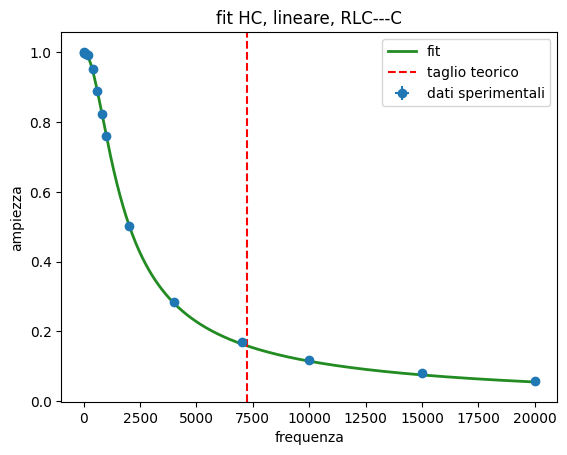

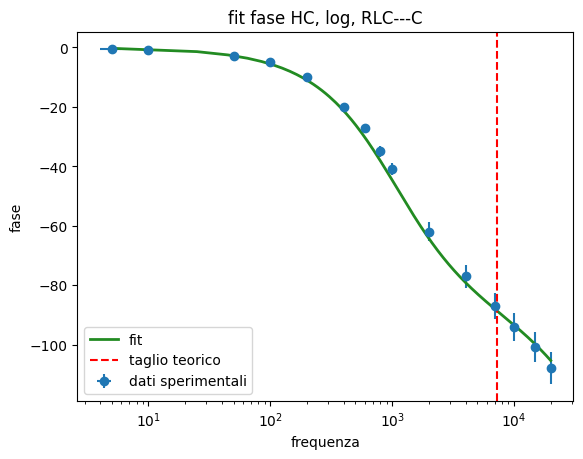

In [51]:
 #plot fit 1 ampiezza
plot_fit_ampiezza(FrlC , HCrlc, errHCrlc , HCrlC , my_minuit14, frlc2, "fit HC, lineare, RLC---C")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)

#plot fit 2 fase
plot_fit_fase_logx(FrlC , faseHCrlc, np.abs(faseHCrlc*(5/100)) ,argHCrlc , my_minuit15,frlc2, "fit fase HC, log, RLC---C")
#plt.savefig("RC_scarica.png")
plt.show()
#plt.close(fig)
